In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from numba import njit

This notebook demonstrates the fitting of n-dimensional memory kernel matrices with multi-exponential matrices. The code is generally accelerated for the simultaneous fitting of all entries.

In [2]:
def create_matrix(arr, n_dim):
    size = n_dim * (n_dim + 1)/2
    if len(arr) != size:
        raise ValueError("Array length does not match the required size for the given n_dim")

    matrix = np.zeros((n_dim, n_dim))

    k = 0
    for i in range(n_dim):
        for j in range(n_dim):
            if i == j:
                matrix[i, j] = arr[k]
                k += 1
            elif i < j:
                matrix[i, j] = arr[k]
                matrix[j, i] = arr[k]
                k += 1

    return matrix

@njit()
def sqrtm(X):
    # Computing diagonalization
    evalues, evectors = np.linalg.eig(X)
    # Ensuring square root matrix exists
    assert (evalues >= 0).all()
    sqrt_matrix = evectors @ np.diag(np.sqrt(evalues)) @ np.linalg.inv(evectors)
    return np.real(sqrt_matrix)

def eigy_expm(A):
    vals,vects = np.linalg.eig(A)
    return np.einsum('...ik, ...k, ...kj -> ...ij',
                     vects,np.exp(vals),np.linalg.inv(vects))

def func_exp(t,params,check=True):

    n_dim = ((np.sqrt(4*len(params)+1)-1)/2).astype(int)

    gammas = create_matrix(params[:len(params)//2],n_dim)
    taus = create_matrix(params[len(params)//2:],n_dim)
    
    ks = np.dot(gammas,np.linalg.inv(taus))
    
    A = np.zeros([len(t),n_dim,n_dim])
    for i in range(len(t)):
        A[i] = -t[i]*np.linalg.inv(taus)

    expA = eigy_expm(A)
    func_ana  = np.einsum('jk,ikl -> ijl',ks,expA)
    
    if check: #has do be invertible, otherwise no good fit params
        try: 
            a = sqrtm(np.linalg.inv(gammas))
        except:
            func_ana*=10000
    
    
    return func_ana


def func_int_exp(t,params,check=True):
    
    n_dim = ((np.sqrt(4*len(params)+1)-1)/2).astype(int)
            
    gammas = create_matrix(params[:len(params)//2],n_dim)    
    taus = create_matrix(params[len(params)//2:],n_dim)
    
    A = np.zeros([len(t),n_dim,n_dim])
    for i in range(len(t)):
        A[i] = -t[i]*np.linalg.inv(taus)

    expA = eigy_expm(A)
    func_ana  = np.einsum('jk,ikl -> ijl',gammas,(np.identity(n_dim) - expA))
    
    if check: #checks whether gamma-matrix is invertible, which is important for Markovian embedding
        try: 
            a = sqrtm(np.linalg.inv(gammas))
        except:
            func_ana*=10000
    
    
    return func_ana


def func_exp_multi(t,params):

    n_dim = ((np.sqrt(4*int(len(params)/N_exp)+1)-1)/2).astype(int)
    size = int((n_dim**2+n_dim)/2)

    gammas = params[:len(params)//2]
    taus = params[len(params)//2:]

    func = np.zeros((len(t),n_dim,n_dim))
    for i in range(N_exp):

        p = np.concatenate((gammas[i*size:(i+1)*size],taus[i*size:(i+1)*size]))
        func += func_exp(t,p)

    return func

def func_int_exp_multi(t,params):

    n_dim = ((np.sqrt(4*int(len(params)/N_exp)+1)-1)/2).astype(int)
    size = int((n_dim**2+n_dim)/2)

    gammas = params[:len(params)//2]
    taus = params[len(params)//2:]

    func = np.zeros((len(t),n_dim,n_dim))
    for i in range(N_exp):

        p = np.concatenate((gammas[i*size:(i+1)*size],taus[i*size:(i+1)*size]))
        func += func_int_exp(t,p)
    
    return func
    



### Create dummy data
2x2 multi-exponential memory kernel matrix. We assume symmetric matrices to reduce the parameter space.

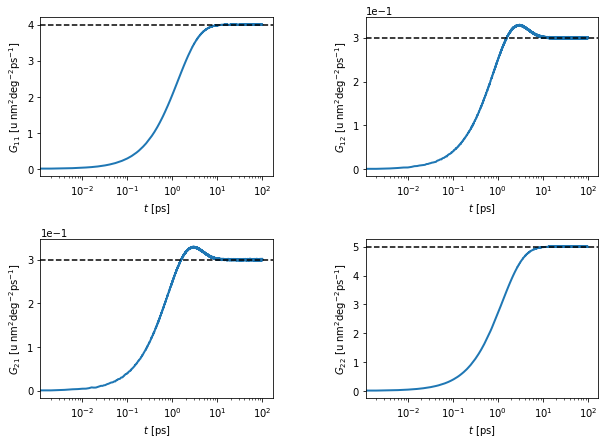

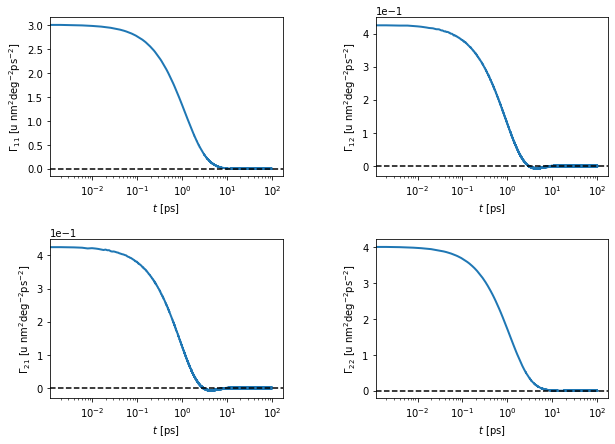

In [3]:
gammas = np.array([[1,0.2,2],[2,0.05,1],[1,0.05,2]])
taus = np.array([[1,0,1],[2,-0.1,1],[1,-0.1,2]])

N_exp = 3

dt = 2e-3
t = np.arange(0,100,dt)
n_dim = 2

kernel_matrix = func_exp_multi(t,np.concatenate([gammas.flatten(),taus.flatten()])) + np.random.normal(0,0.0005,(len(t),n_dim,n_dim))
ikernel_matrix = func_int_exp_multi(t,np.concatenate([gammas.flatten(),taus.flatten()])) + np.random.normal(0,0.0005,(len(t),n_dim,n_dim))

gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(gammas[i],n_dim)

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,ikernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,kernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()



### Fit the data 
Use logspaced data. We fit the memory kernel and its running integral in parallel for a better agreement of short- and long-time data.

#### Fit all entries at once

[ 1.08851997e+00  2.90660468e-01  1.53575798e+00  9.42834828e-01
  2.58460542e-01  1.49048066e+00  1.96864982e+00 -2.49063294e-01
  1.97376365e+00  1.03067265e+00  3.67987369e-08  9.79215370e-01
  9.61136454e-01  1.24156673e-05  1.01697131e+00  2.01278606e+00
  2.06450996e-03  2.01189438e+00] [ 1.    0.2   2.    2.    0.05  1.    1.    0.05  2.    1.    0.    1.
  2.   -0.1   1.    1.   -0.1   2.  ]
[1.65545861e+01 4.02591186e+00 6.37372412e+01 1.66006769e+01
 4.01475855e+00 6.37155727e+01 4.82027398e-02 1.26120624e-02
 2.52544679e-02 6.62834652e-01 1.33367674e-01 7.61203906e-01
 5.65378707e-01 1.95987477e-01 8.96733111e-01 1.06195943e-02
 3.88494185e-03 5.86686877e-03]


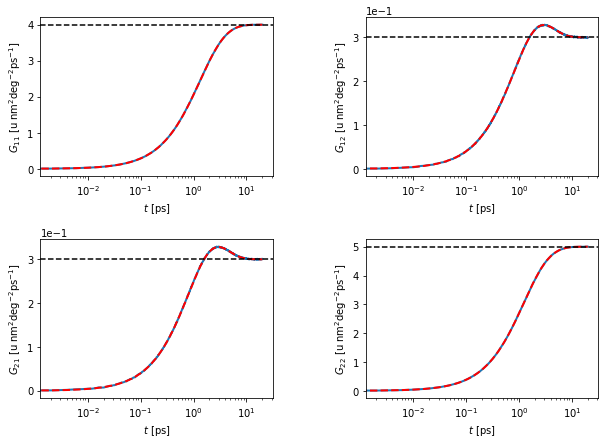

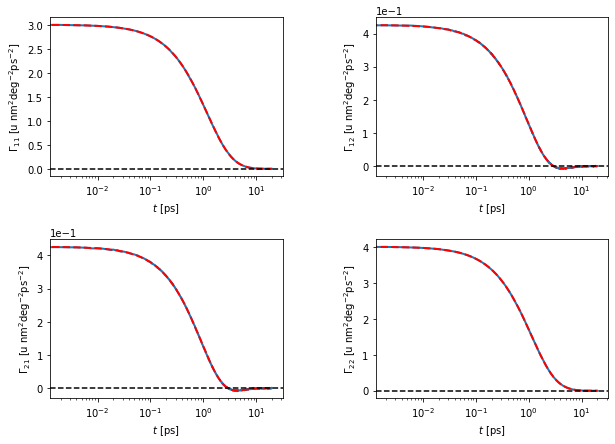

In [4]:
def fit_func(t,*params):
    obj1 = func_int_exp_multi(t,params)
    obj2 = func_exp_multi(t,params)

    return np.append(obj1.flatten(),obj2.flatten())

n_dim = 2
N_exp = 3

start =0
end = 4.0
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

t_logsp = t[logsp]
ikernel_logsp = ikernel_matrix[logsp]
kernel_logsp = kernel_matrix[logsp]

g1 = 1.8
g2 = 0.8
g3 = 0.5
t1 = 1
t2 = 1
t3 = 1

lower_lim_gamma = 1e-3
upper_lim_gamma = 1e3

lower_lim_tau = 1e-3
upper_lim_tau = 1e3

p0 = np.array([[g1,g1/10,g1],
        [g2,g2/10,g2],
        [g3,g3/10,g3],
        [t1,0,t1],
        [t2,0,t2],
        [t2,0,t2]]).flatten()


bounds = [np.array([[lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_tau,0,lower_lim_tau],
        [lower_lim_tau,0,lower_lim_tau],
        [lower_lim_tau,0,lower_lim_tau]]).flatten(),
        np.array([[upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau]]).flatten()]

popt = p0
popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.flatten(),kernel_logsp.flatten()), p0=popt, bounds=bounds)
print(popt,np.concatenate([gammas.flatten(),taus.flatten()]))
print(np.sqrt(np.diag(pcov)))

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_int_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

##### Create an ndarray for better visibility of parameters

In [5]:
gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(popt[:len(popt)//2][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

tausm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    tausm[i] = create_matrix(popt[len(popt)//2:][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

print(gammasm)
print(tausm)




[[[ 1.08851997  0.29066047]
  [ 0.29066047  1.53575798]]

 [[ 0.94283483  0.25846054]
  [ 0.25846054  1.49048066]]

 [[ 1.96864982 -0.24906329]
  [-0.24906329  1.97376365]]]
[[[1.03067265e+00 3.67987369e-08]
  [3.67987369e-08 9.79215370e-01]]

 [[9.61136454e-01 1.24156673e-05]
  [1.24156673e-05 1.01697131e+00]]

 [[2.01278606e+00 2.06450996e-03]
  [2.06450996e-03 2.01189438e+00]]]


#### This procedure is rather slow. First fit diagonal entries with 1D kernels (as initial guesses, its much faster and reduces parameters to adjust)
Moreover, we use tight boundaries for the diagonal entries in the matrix fitting.

[1.99152950e+00 2.00458071e+00 2.00799767e+00 9.93200299e-01
 3.00256452e-02 9.75111953e+02]
[1.00000000e-03 4.32399950e-01 1.97165396e+00 2.01288307e+00
 3.02737324e+00 9.98019265e-01]


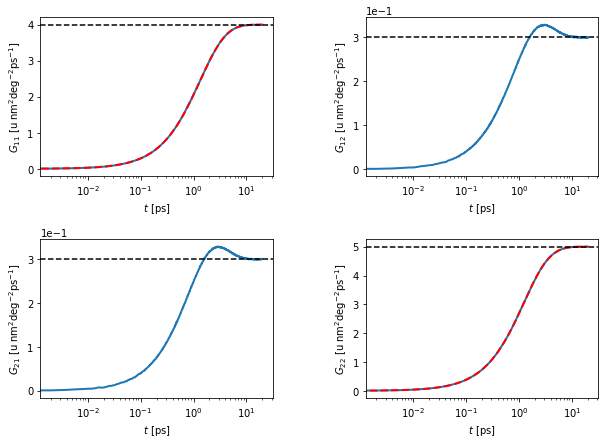

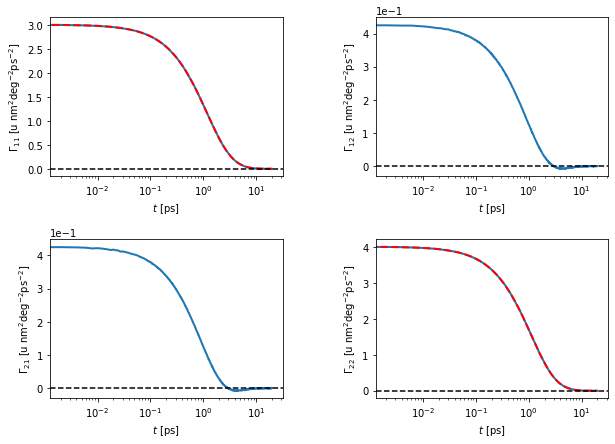

In [6]:
def func_exp_1D(t,*params):
    N = int(len(params)/2)
    func = np.zeros(len(t))
    for i in range(0,2*N,2):
        gamma,tau = params[i:i+2]
        func+= gamma/tau*np.exp(-t/tau)
        
    return func

def func_int_exp_1D(t,*params):
    N = int(len(params)/2)
    func = np.zeros(len(t))
    for i in range(0,2*N,2):
        gamma,tau = params[i:i+2]
        func+= gamma*(1-np.exp(-t/tau))

    return func
    
def fit_func(t,*params):
    func1 = func_int_exp_1D(t,*params)
    func2 = func_exp_1D(t,*params)
    
    return np.append(func1, func2)


start =0
end = 4.0
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

t_logsp = t[logsp]
ikernel_logsp = ikernel_matrix[logsp]
kernel_logsp = kernel_matrix[logsp]

g1 = 1.8
g2 = 0.8
g3 = 0.5
t1 = 1
t2 = 1
t3 = 1

lower_lim_gamma = 1e-3
upper_lim_gamma = 1e3

lower_lim_tau = 1e-3
upper_lim_tau = 1e3

p_diag = np.zeros((n_dim,N_exp*2))

p0 = np.array([g1,t1,g2,t2,g3,t3])

bounds = [[lower_lim_gamma,lower_lim_tau,lower_lim_gamma,lower_lim_tau,lower_lim_gamma,lower_lim_tau],
          [upper_lim_gamma,upper_lim_tau,upper_lim_gamma,upper_lim_tau,upper_lim_gamma,upper_lim_tau]]

for i in range(n_dim):
    popt = p0
    popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.T[i][i],kernel_logsp.T[i][i]), p0=popt, bounds=bounds,maxfev=10000)
    print(popt)

    #need to sort the gammas by size otherwise not stable in simulations later on...
    idx1 = np.argsort(popt[::2])
    popt[::2] = popt[::2][idx1]
    popt[1::2] = popt[1::2][idx1]
    
    p_diag[i] = popt

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        if i == j:
            ax[i][j].plot(t[logsp],func_int_exp_1D(t[logsp],*p_diag[i]),'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()


fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        if i == j:
            ax[i][j].plot(t[logsp],func_exp_1D(t[logsp],*p_diag[i]),'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

In [7]:
p_diag

array([[3.00256452e-02, 9.75111953e+02, 1.99152950e+00, 2.00458071e+00,
        2.00799767e+00, 9.93200299e-01],
       [1.00000000e-03, 4.32399950e-01, 1.97165396e+00, 2.01288307e+00,
        3.02737324e+00, 9.98019265e-01]])

[ 2.85243629e-02  6.23734651e-05  9.50000000e-04  1.98428108e+00
 -2.57192584e-01  1.98045477e+00  2.01533780e+00  5.57314778e-01
  3.01856283e+00  1.02386755e+03 -2.16199632e-01  4.54019947e-01
  2.00832495e+00  5.54447204e-03  2.01011188e+00  9.94024615e-01
  1.26551367e-03  9.96784461e-01] [ 1.    0.2   2.    2.    0.05  1.    1.    0.05  2.    1.    0.    1.
  2.   -0.1   1.    1.   -0.1   2.  ]
[3.23996592e+00 9.37368756e-03 2.26559786e-03 3.64472773e-03
 3.99248559e-03 5.24241715e-03 3.80686653e-03 3.89054737e-03
 4.58541412e-03 1.17812980e+05 3.46514254e+02 4.16572403e-01
 2.06143961e-03 2.00684201e-03 2.02462120e-03 5.56091502e-04
 5.30354801e-04 9.09708112e-04]


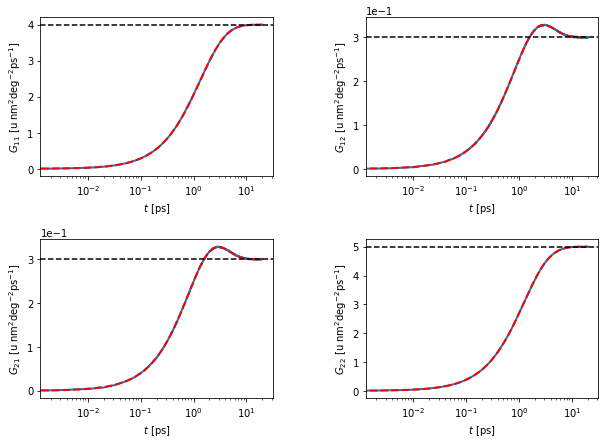

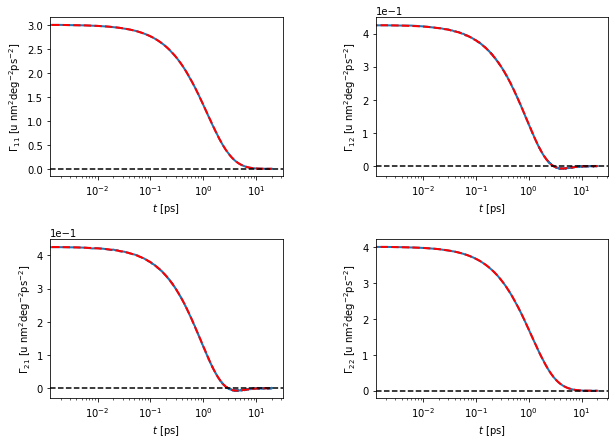

In [8]:
def fit_func(t,*params):
    obj1 = func_int_exp_multi(t,params)
    obj2 = func_exp_multi(t,params)

    return np.append(obj1.flatten(),obj2.flatten())

n_dim = 2
N_exp = 3

start =0
end = 4.0
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

f_min = 0.95
f_max = 1.05

t_logsp = t[logsp]
ikernel_logsp = ikernel_matrix[logsp]
kernel_logsp = kernel_matrix[logsp]

p0 = np.array([[p_diag[0][0],np.min([p_diag[0][0],p_diag[1][0]])/10,p_diag[1][0]],
        [p_diag[0][2],np.min([p_diag[0][2],p_diag[1][2]])/10,p_diag[1][2]],
        [p_diag[0][4],np.min([p_diag[0][4],p_diag[1][4]])/10,p_diag[1][4]],
        [p_diag[0][1],np.min([p_diag[0][1],p_diag[1][1]])/10,p_diag[1][1]],
        [p_diag[0][3],np.min([p_diag[0][3],p_diag[1][3]])/10,p_diag[1][3]],
        [p_diag[0][5],np.min([p_diag[0][5],p_diag[1][5]])/10,p_diag[1][5]]]).flatten()

#use tight boundaries for diag entries (needs to be automatized with for-loop later...)
bounds = [np.array([[p_diag[0][0]*f_min,-np.min([p_diag[0][0],p_diag[1][0]])/2,p_diag[1][0]*f_min],
        [p_diag[0][2]*f_min,-np.min([p_diag[0][2],p_diag[1][2]])/2,p_diag[1][2]*f_min],
        [p_diag[0][4]*f_min,-np.min([p_diag[0][4],p_diag[1][4]])/2,p_diag[1][4]*f_min],
        [p_diag[0][1]*f_min,-np.min([p_diag[0][1],p_diag[1][1]])/2,p_diag[1][1]*f_min],
        [p_diag[0][3]*f_min,-np.min([p_diag[0][3],p_diag[1][3]])/2,p_diag[1][3]*f_min],
        [p_diag[0][5]*f_min,-np.min([p_diag[0][5],p_diag[1][5]])/2,p_diag[1][5]*f_min]]).flatten(),
        np.array([[p_diag[0][0]*f_max,np.min([p_diag[0][0],p_diag[1][0]])/2,p_diag[1][0]*f_max],
        [p_diag[0][2]*f_max,np.min([p_diag[0][2],p_diag[1][2]])/2,p_diag[1][2]*f_max],
        [p_diag[0][4]*f_max,np.min([p_diag[0][4],p_diag[1][4]])/2,p_diag[1][4]*f_max],
        [p_diag[0][1]*f_max,np.min([p_diag[0][1],p_diag[1][1]])/2,p_diag[1][1]*f_max],
        [p_diag[0][3]*f_max,np.min([p_diag[0][3],p_diag[1][3]])/2,p_diag[1][3]*f_max],
        [p_diag[0][5]*f_max,np.min([p_diag[0][5],p_diag[1][5]])/2,p_diag[1][5]*f_max]]).flatten()]

popt = p0
popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.flatten(),kernel_logsp.flatten()), p0=popt, bounds=bounds)
print(popt,np.concatenate([gammas.flatten(),taus.flatten()]))
print(np.sqrt(np.diag(pcov)))

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_int_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

In [9]:
gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(popt[:len(popt)//2][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

tausm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    tausm[i] = create_matrix(popt[len(popt)//2:][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

print(gammasm)
print(tausm)

[[[ 2.85243629e-02  6.23734651e-05]
  [ 6.23734651e-05  9.50000000e-04]]

 [[ 1.98428108e+00 -2.57192584e-01]
  [-2.57192584e-01  1.98045477e+00]]

 [[ 2.01533780e+00  5.57314778e-01]
  [ 5.57314778e-01  3.01856283e+00]]]
[[[ 1.02386755e+03 -2.16199632e-01]
  [-2.16199632e-01  4.54019947e-01]]

 [[ 2.00832495e+00  5.54447204e-03]
  [ 5.54447204e-03  2.01011188e+00]]

 [[ 9.94024615e-01  1.26551367e-03]
  [ 1.26551367e-03  9.96784461e-01]]]


### Test for 3x3 Kernel

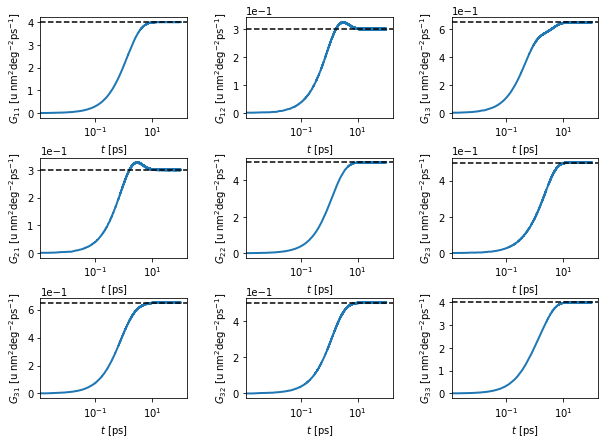

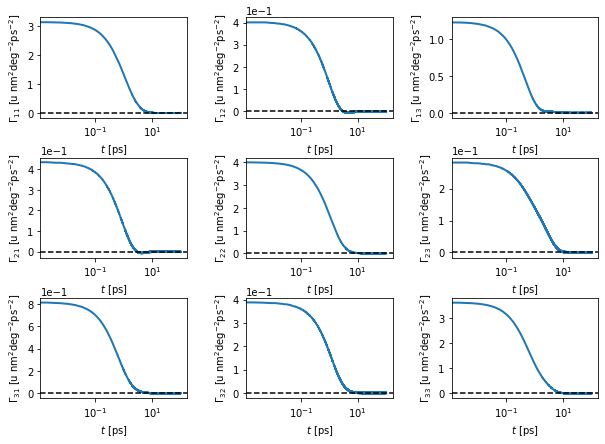

In [10]:
gammas = np.array([[1,0.2,0.1,2,0.2,2],[2,0.05,0.05,1,0.2,1],[1,0.05,0.5,2,0.1,1]])
taus = np.array([[1,0,0.01,1,0.02,2],[2,-0.1,0.1,1,0.05,2],[1,-0.1,-0.1,2,0.05,0.5]])

N_exp = 3

dt = 2e-3
t = np.arange(0,100,dt)
n_dim = 3

kernel_matrix = func_exp_multi(t,np.concatenate([gammas.flatten(),taus.flatten()])) + np.random.normal(0,0.0005,(len(t),n_dim,n_dim))
ikernel_matrix = func_int_exp_multi(t,np.concatenate([gammas.flatten(),taus.flatten()])) + np.random.normal(0,0.0005,(len(t),n_dim,n_dim))

gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(gammas[i],n_dim)

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,ikernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,kernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()



[ 2.40750209e+00 -3.34878039e-01  1.82820834e-01  1.39456969e+00
 -7.11947550e-01  3.63519830e-01  4.96289245e-01  3.98356293e-01
  6.63654457e-01  2.74606782e+00  1.15550033e-01  1.06468023e+00
  1.09319246e+00  2.37660734e-01 -1.95902837e-01  8.59838761e-01
  1.09596547e+00  2.57179043e+00  1.86568569e+00  6.57991997e-02
  1.06391998e-01  2.09253663e+00  6.11591647e-05  1.94277790e+00
  6.82824381e-01  4.51891670e-02  1.11662945e-07  1.04303292e+00
  7.13143489e-03  4.80417366e-01  9.56479473e-01  4.63727763e-02
  1.67217226e-02  9.51317211e-01  3.73741995e-01  1.87808368e+00] [ 1.    0.2   0.1   2.    0.2   2.    2.    0.05  0.05  1.    0.2   1.
  1.    0.05  0.5   2.    0.1   1.    1.    0.    0.01  1.    0.02  2.
  2.   -0.1   0.1   1.    0.05  2.    1.   -0.1  -0.1   2.    0.05  0.5 ]
[0.01746768 0.01153453 0.02285059 0.01800081 0.02919181 0.04416717
 0.01834595 0.0287739  0.00120303 0.01558659 0.00618225 0.001227
 0.01118273 0.01948953 0.02256793 0.0140202  0.03267363 0.04427549

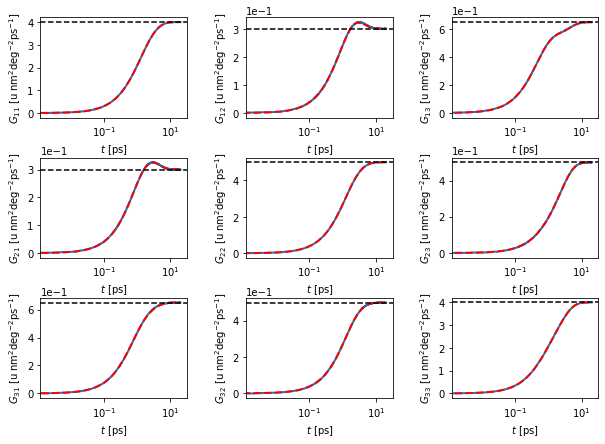

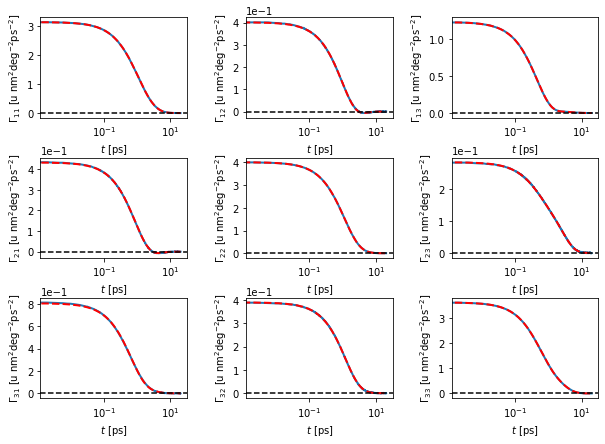

In [11]:
def fit_func(t,*params):
    obj1 = func_int_exp_multi(t,params)
    obj2 = func_exp_multi(t,params)

    return np.append(obj1.flatten(),obj2.flatten())

n_dim = 3
N_exp = 3

start =0
end = 4.0
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

t_logsp = t[logsp]
ikernel_logsp = ikernel_matrix[logsp]
kernel_logsp = kernel_matrix[logsp]

g1 = 1.8
g2 = 0.8
g3 = 0.5
t1 = 1
t2 = 1
t3 = 1

lower_lim_gamma = 1e-3
upper_lim_gamma = 1e3

lower_lim_tau = 1e-3
upper_lim_tau = 1e3

p0 = np.array([[g1,g1/10,g1/10,g1,g1/10,g1],
        [g2,g2/10,g2/10,g2,g2/10,g2],
        [g3,g3/10,g3/10,g3,g3/10,g3],
        [t1,0,0,t1,0,t1],
        [t2,0,0,t2,0,t2],
        [t3,0,0,t3,0,t3]]).flatten()


bounds = [np.array([[lower_lim_gamma,-upper_lim_gamma/2,-upper_lim_gamma/2,lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_gamma,-upper_lim_gamma/2,-upper_lim_gamma/2,lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_gamma,-upper_lim_gamma/2,-upper_lim_gamma/2,lower_lim_gamma,-upper_lim_gamma/2,lower_lim_gamma],
        [lower_lim_tau,0,0,lower_lim_tau,0,lower_lim_tau],
        [lower_lim_tau,0,0,lower_lim_tau,0,lower_lim_tau],
        [lower_lim_tau,0,0,lower_lim_tau,0,lower_lim_tau]]).flatten(),
        np.array([[upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma/2,upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma/2,upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma/2,upper_lim_gamma,upper_lim_gamma/2,upper_lim_gamma],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau],
        [upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau,upper_lim_tau]]).flatten()]

popt = p0
popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.flatten(),kernel_logsp.flatten()), p0=popt, bounds=bounds)
print(popt,np.concatenate([gammas.flatten(),taus.flatten()]))
print(np.sqrt(np.diag(pcov)))

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_int_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

In [12]:
gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(popt[:len(popt)//2][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

tausm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    tausm[i] = create_matrix(popt[len(popt)//2:][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

print(gammasm)
print(tausm)

[[[ 2.40750209 -0.33487804  0.18282083]
  [-0.33487804  1.39456969 -0.71194755]
  [ 0.18282083 -0.71194755  0.36351983]]

 [[ 0.49628924  0.39835629  0.66365446]
  [ 0.39835629  2.74606782  0.11555003]
  [ 0.66365446  0.11555003  1.06468023]]

 [[ 1.09319246  0.23766073 -0.19590284]
  [ 0.23766073  0.85983876  1.09596547]
  [-0.19590284  1.09596547  2.57179043]]]
[[[1.86568569e+00 6.57991997e-02 1.06391998e-01]
  [6.57991997e-02 2.09253663e+00 6.11591647e-05]
  [1.06391998e-01 6.11591647e-05 1.94277790e+00]]

 [[6.82824381e-01 4.51891670e-02 1.11662945e-07]
  [4.51891670e-02 1.04303292e+00 7.13143489e-03]
  [1.11662945e-07 7.13143489e-03 4.80417366e-01]]

 [[9.56479473e-01 4.63727763e-02 1.67217226e-02]
  [4.63727763e-02 9.51317211e-01 3.73741995e-01]
  [1.67217226e-02 3.73741995e-01 1.87808368e+00]]]


### Apply on real data (pentane dihedrals)


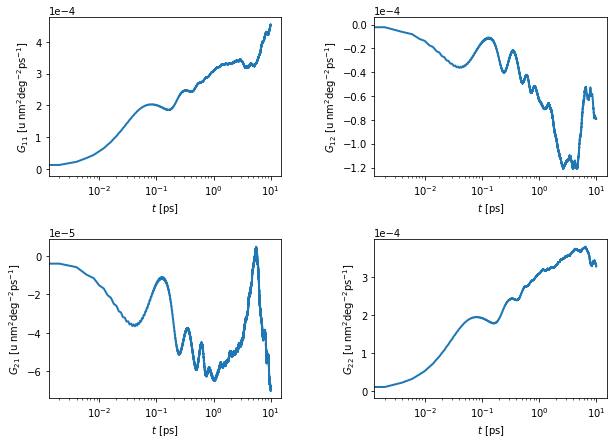

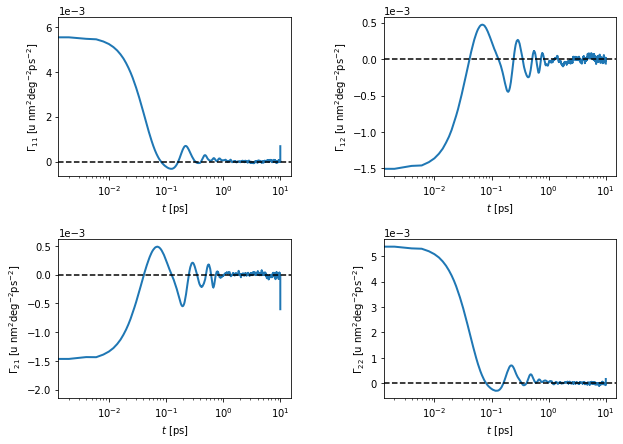

In [13]:
#extracted in the notebook example_extraction.ipynb

N_exp = 3
dt = 2e-3
n_dim = 2

kernel_matrix = np.load('2d_kernel_pentane.npy')
ikernel_matrix = np.load('2d_ikernel_pentane.npy',)
t = np.arange(0,len(kernel_matrix)*dt,dt)



fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,ikernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t,kernel_matrix[:,i,j],lw=2)
        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()


[1.66647253e-04 1.46370982e+00 1.19384989e-04 2.96626414e-02
 8.67562870e-05 2.96631647e-02]
[1.83232431e-04 1.36847189e+00 1.01752487e-07 2.97995527e-02
 1.95014239e-04 2.97716383e-02]


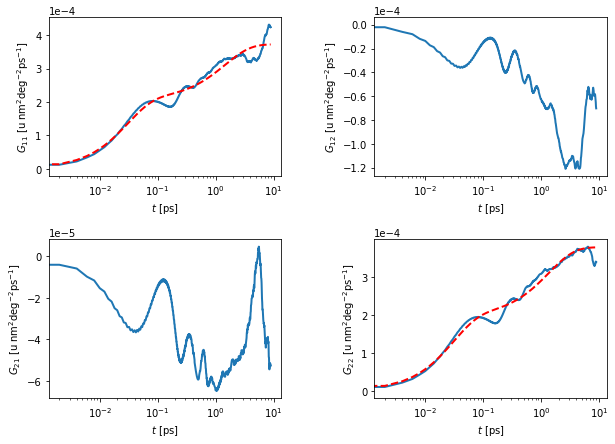

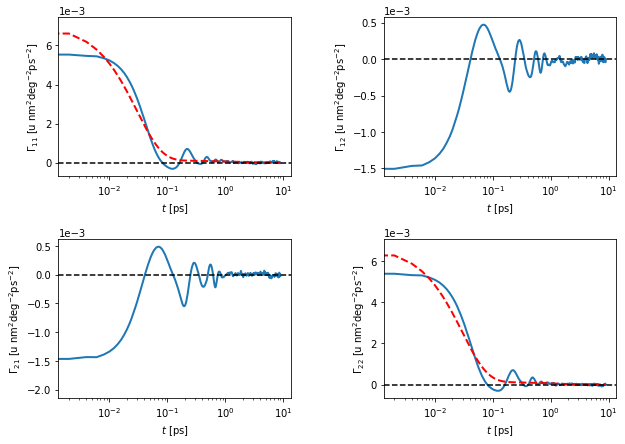

In [14]:
def func_exp_1D(t,*params):
    N = int(len(params)/2)
    func = np.zeros(len(t))
    for i in range(0,2*N,2):
        gamma,tau = params[i:i+2]
        func+= gamma/tau*np.exp(-t/tau)
        
    return func

def func_int_exp_1D(t,*params):
    N = int(len(params)/2)
    func = np.zeros(len(t))
    for i in range(0,2*N,2):
        gamma,tau = params[i:i+2]
        func+= gamma*(1-np.exp(-t/tau))

    return func
    
def fit_func(t,*params):
    func1 = func_int_exp_1D(t,*params)
    func2 = func_exp_1D(t,*params)
    
    return np.append(func1, func2)


start =0
end = 3.65
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

t_logsp = t[logsp]
ikernel_logsp = ikernel_matrix[logsp]
kernel_logsp = kernel_matrix[logsp]

g1 = 1.8e-4
g2 = 0.8e-4
g3 = 0.5e-4
t1 = 1
t2 = .1
t3 = .1

lower_lim_gamma = 1e-7
upper_lim_gamma = 1e-3

lower_lim_tau = 1e-3
upper_lim_tau = 1e3

p_diag = np.zeros((n_dim,N_exp*2))

p0 = np.array([g1,t1,g2,t2,g3,t3])

bounds = [[lower_lim_gamma,lower_lim_tau,lower_lim_gamma,lower_lim_tau,lower_lim_gamma,lower_lim_tau],
          [upper_lim_gamma,upper_lim_tau,upper_lim_gamma,upper_lim_tau,upper_lim_gamma,upper_lim_tau]]

for i in range(n_dim):
    popt = p0
    popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.T[i][i],kernel_logsp.T[i][i]), p0=popt, bounds=bounds,maxfev=10000)
    print(popt)

    #need to sort the gammas by size otherwise not stable in simulations later on...
    idx1 = np.argsort(popt[::2])
    popt[::2] = popt[::2][idx1]
    popt[1::2] = popt[1::2][idx1]
    
    p_diag[i] = popt

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        if i == j:
            ax[i][j].plot(t[logsp],func_int_exp_1D(t[logsp],*p_diag[i]),'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))

plt.show()


fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        if i == j:
            ax[i][j].plot(t[logsp],func_exp_1D(t[logsp],*p_diag[i]),'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

In [15]:
p_diag

array([[8.67562870e-05, 2.96631647e-02, 1.19384989e-04, 2.96626414e-02,
        1.66647253e-04, 1.46370982e+00],
       [1.01752487e-07, 2.97995527e-02, 1.83232431e-04, 1.36847189e+00,
        1.95014239e-04, 2.97716383e-02]])

Note that the friction matrix entries will not be perfect as the long time limits of the running integrals will scatter due to limited trajectory length. To improve this, we assume the maximal value before the scattering as plateau value. We also average the off-diagonal entries for better statistics. However, this should be also done, if the diagonal entries (theoretically) are the same!

In [19]:
def correct_data(t,kernel_matrix,ikernel_matrix,n_dim,start=0,end=3.99,amount=100,avg=True,correct=True):
    
    #averaging off-diag entries since they should be the same
    if avg:
        for i in range(n_dim):
            for j in range(n_dim):
                if i!=j:
                    ikernel_matrix.T[i][j] = (ikernel_matrix.T[i][j] + ikernel_matrix.T[j][i])/2
                    kernel_matrix.T[i][j] = (kernel_matrix.T[i][j] + kernel_matrix.T[j][i])/2
                    kernel_matrix.T[j][i] = kernel_matrix.T[i][j]
                    ikernel_matrix.T[j][i] = ikernel_matrix.T[i][j]
    

    logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

    t_logsp = t[logsp]
    ikernel_logsp = ikernel_matrix[logsp]
    kernel_logsp = kernel_matrix[logsp]
    
    if correct:
        for i in range(n_dim):
            for j in range(n_dim):
                if i!=j:
                    if kernel_logsp.T[j][i][0] < 0:
                        min1 = np.argmin(ikernel_logsp.T[j][i])
                        ikernel_logsp.T[j][i] = np.append(ikernel_logsp.T[j][i][:min1],np.ones((len(ikernel_logsp.T[j][i])-min1))*ikernel_logsp.T[j][i][min1])
                        kernel_logsp.T[j][i] = np.append(kernel_logsp.T[j][i][:min1],np.zeros((len(kernel_logsp.T[j][i])-min1)))
                    else:
                        max1 = np.argmax(ikernel_logsp.T[j][i])
                        ikernel_logsp.T[j][i] = np.append(ikernel_logsp.T[j][i][:max1],np.ones((len(ikernel_logsp.T[j][i])-max1))*ikernel_logsp.T[j][i][max1])
                        kernel_logsp.T[j][i] = np.append(kernel_logsp.T[j][i][:max1],np.zeros((len(kernel_logsp.T[j][i])-max1)))
                if i==j:
                    max1 = np.argmax(ikernel_logsp.T[i][i])
                    ikernel_logsp.T[i][i] = np.append(ikernel_logsp.T[i][i][:max1],np.ones((len(ikernel_logsp.T[i][i])-max1))*ikernel_logsp.T[i][i][max1])
                    kernel_logsp.T[i][i] = np.append(kernel_logsp.T[i][i][:max1],np.zeros((len(kernel_logsp.T[i][i])-max1)))

    return t_logsp,ikernel_logsp,kernel_logsp

[ 1.04107544e-04  5.08762435e-08  1.22102985e-07  1.00665868e-04
 -4.34726393e-05  1.89306974e-04  1.70041606e-04 -2.91019948e-05
  1.93909793e-04  3.37520631e-02  8.85882848e-03  3.43927813e-02
  2.64627767e-02 -4.53333893e-03  1.36927731e+00  1.46213121e+00
 -1.46369242e-02  2.95441054e-02]
[2.50366501e-04 2.55763935e-04 2.25427044e-04 2.15669472e-04
 1.14851484e-04 4.15375371e-05 4.72822475e-05 1.65336621e-04
 1.90862689e-04 1.66483012e-02 2.12720392e-02 1.74457611e-02
 1.46479183e-02 2.24715492e+00 2.15141374e-01 2.98111898e-01
 1.87078507e+00 4.16760932e-02]
[[[ 1.04107544e-04  5.08762435e-08]
  [ 5.08762435e-08  1.22102985e-07]]

 [[ 1.00665868e-04 -4.34726393e-05]
  [-4.34726393e-05  1.89306974e-04]]

 [[ 1.70041606e-04 -2.91019948e-05]
  [-2.91019948e-05  1.93909793e-04]]]
[[[ 0.03375206  0.00885883]
  [ 0.00885883  0.03439278]]

 [[ 0.02646278 -0.00453334]
  [-0.00453334  1.36927731]]

 [[ 1.46213121 -0.01463692]
  [-0.01463692  0.02954411]]]


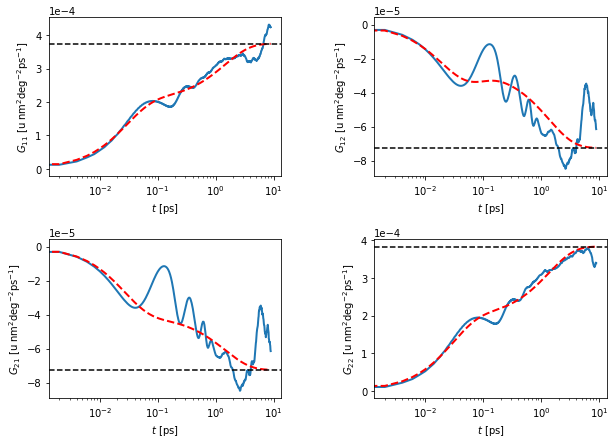

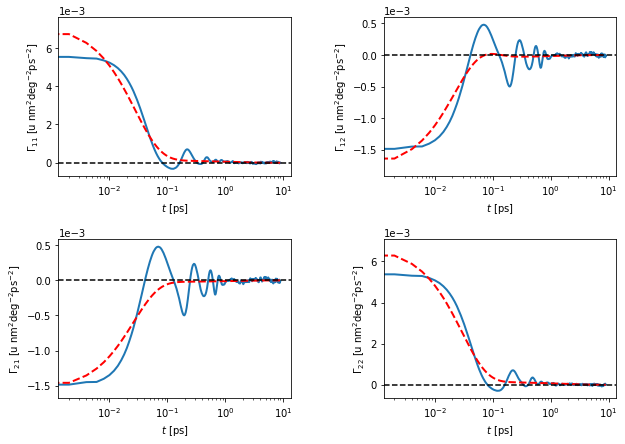

In [20]:
def fit_func(t,*params):
    obj1 = func_int_exp_multi(t,params)
    obj2 = func_exp_multi(t,params)

    return np.append(obj1.flatten(),obj2.flatten())

n_dim = 2
N_exp = 3

start =0
end = 3.65
amount =1000
logsp = np.append(0,np.unique(np.logspace(start,end,amount).astype(int)))

#t_logsp = t[logsp]
#ikernel_logsp = ikernel_matrix[logsp]
#kernel_logsp = kernel_matrix[logsp]

t_logsp,ikernel_logsp,kernel_logsp = correct_data(t,kernel_matrix,ikernel_matrix,n_dim,start=start,end=end,amount=amount,avg=True,correct=True)

f_min = 0.8
f_max = 1.2

p0 = np.array([[p_diag[0][0],np.min([p_diag[0][0],p_diag[1][0]])/10,p_diag[1][0]],
        [p_diag[0][2],np.min([p_diag[0][2],p_diag[1][2]])/10,p_diag[1][2]],
        [p_diag[0][4],np.min([p_diag[0][4],p_diag[1][4]])/10,p_diag[1][4]],
        [p_diag[0][1],np.min([p_diag[0][1],p_diag[1][1]])/10,p_diag[1][1]],
        [p_diag[0][3],np.min([p_diag[0][3],p_diag[1][3]])/10,p_diag[1][3]],
        [p_diag[0][5],np.min([p_diag[0][5],p_diag[1][5]])/10,p_diag[1][5]]]).flatten()

#use tight boundaries for diag entries (needs to be automatized with for-loop later...)
bounds = [np.array([[p_diag[0][0]*f_min,-np.min([p_diag[0][0],p_diag[1][0]])/2,p_diag[1][0]*f_min],
        [p_diag[0][2]*f_min,-np.min([p_diag[0][2],p_diag[1][2]])/2,p_diag[1][2]*f_min],
        [p_diag[0][4]*f_min,-np.min([p_diag[0][4],p_diag[1][4]])/2,p_diag[1][4]*f_min],
        [p_diag[0][1]*f_min,-np.min([p_diag[0][1],p_diag[1][1]])/2,p_diag[1][1]*f_min],
        [p_diag[0][3]*f_min,-np.min([p_diag[0][3],p_diag[1][3]])/2,p_diag[1][3]*f_min],
        [p_diag[0][5]*f_min,-np.min([p_diag[0][5],p_diag[1][5]])/2,p_diag[1][5]*f_min]]).flatten(),
        np.array([[p_diag[0][0]*f_max,np.min([p_diag[0][0],p_diag[1][0]])/2,p_diag[1][0]*f_max],
        [p_diag[0][2]*f_max,np.min([p_diag[0][2],p_diag[1][2]])/2,p_diag[1][2]*f_max],
        [p_diag[0][4]*f_max,np.min([p_diag[0][4],p_diag[1][4]])/2,p_diag[1][4]*f_max],
        [p_diag[0][1]*f_max,np.min([p_diag[0][1],p_diag[1][1]])/2,p_diag[1][1]*f_max],
        [p_diag[0][3]*f_max,np.min([p_diag[0][3],p_diag[1][3]])/2,p_diag[1][3]*f_max],
        [p_diag[0][5]*f_max,np.min([p_diag[0][5],p_diag[1][5]])/2,p_diag[1][5]*f_max]]).flatten()]

popt = p0
popt, pcov = curve_fit(fit_func, t_logsp, np.append(ikernel_logsp.flatten(),kernel_logsp.flatten()), p0=popt, bounds=bounds)
print(popt)
print(np.sqrt(np.diag(pcov)))

gammasm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    gammasm[i] = create_matrix(popt[:len(popt)//2][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

tausm = np.zeros((N_exp,n_dim,n_dim))
for i in range(N_exp):
    tausm[i] = create_matrix(popt[len(popt)//2:][i*int((n_dim**2+n_dim)/2):(i+1)*int((n_dim**2+n_dim)/2)],n_dim)

print(gammasm)
print(tausm)

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],ikernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_int_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$G_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-1}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=np.sum(gammasm,axis=0)[i,j],color='k',linestyle='--')

plt.show()

fig, ax = plt.subplots(n_dim,n_dim, figsize=(10,7))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.4)
for i in range(n_dim):
    for j in range(n_dim):
        ax[i][j].plot(t[logsp],kernel_matrix[logsp][:,i,j],lw=2)
        ax[i][j].plot(t[logsp],func_exp_multi(t[logsp],popt)[:,i,j],'r--',lw=2)

        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$ [u nm$^{2}$deg$^{-2}$ps$^{-2}$]' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$ [ps]')
        ax[i][j].set_xscale('log')
        ax[i][j].ticklabel_format(axis = 'y', style = 'sci', scilimits=(0,0))
        ax[i][j].axhline(y=0,color='k',linestyle='--')
plt.show()

### Test stuff

In [18]:
def create_matrix(arr, n_dim):
    size = n_dim * (n_dim + 1)/2
    if len(arr) != size:
        raise ValueError("Array length does not match the required size for the given n_dim")

    matrix = np.zeros((n_dim, n_dim))

    k = 0
    for i in range(n_dim):
        for j in range(n_dim):
            if i == j:
                matrix[i, j] = arr[k]
                k += 1
            elif i < j:
                matrix[i, j] = arr[k]
                matrix[j, i] = arr[k]
                k += 1

    return matrix

# Example usage
#gammas= np.array([1, 2, 3, 4, 5, 6])
#n_dim = 3
#gammas = np.array([1, 2, 4])
#n_dim = 2
gammas = np.array([1, 2, 3, 4, 5 , 6, 7, 8, 9, 10])
n_dim = 4
gammas = create_matrix(gammas, n_dim)
print(gammas)


[[ 1.  2.  3.  4.]
 [ 2.  5.  6.  7.]
 [ 3.  6.  8.  9.]
 [ 4.  7.  9. 10.]]
